🤖 Machine Learning &nbsp;·&nbsp; *Bài 13/23*

[« Machine Learning - Train/Test](012_ml_train_test.ipynb) &nbsp;•&nbsp; [📚 Mục lục](../README.md) &nbsp;•&nbsp; [Machine Learning - Confusion Matrix »](014_ml_confusion_matrix.ipynb)

# Machine Learning - Decision Tree

> 📖 **Học song song trên W3Schools:** [python_ml_decision_tree.asp](https://www.w3schools.com/python/python_ml_decision_tree.asp)
>
> 🎯 **Trong bài này:** Decision Tree · How Does it Work? · Result Explained · Predict Values · Different Results

## Decision Tree — Cây quyết định

Trong bài này, bạn học cách tạo **cây quyết định (decision tree)** — một sơ đồ giúp đưa ra quyết định dựa trên kinh nghiệm trước đó.

Ví dụ: một người đang cân nhắc có nên đi xem một show hài hay không.

May mắn là người đó đã ghi lại thông tin mỗi khi có show hài trong thị trấn: thông tin về nghệ sĩ hài, và mình **có đi xem hay không** (file `shows.csv`):

In [1]:
import pandas

df = pandas.read_csv("shows.csv")

print(df)

    Age  Experience  Rank Nationality   Go
0    45          13     8          UK  YES
1    42          12     3          UK   NO
2    29           8     9         USA  YES
3    28           7     6         USA   NO
4    23           1     4          UK   NO
5    47          20     8           N  YES
6    58           4     9          UK  YES
7    18           1     4         USA   NO
8    47          21     9          UK  YES
9    30          14    10         USA  YES
10   25           2     8          UK   NO
11   47           4     9          UK   NO
12   61          15     9          UK  YES


- `Age` — tuổi nghệ sĩ · `Experience` — số năm kinh nghiệm · `Rank` — xếp hạng (1-10) · `Nationality` — quốc tịch · `Go` — có đi xem không.

Dựa trên dữ liệu này, Python tạo một cây quyết định để quyết định có nên đi xem show mới hay không.

## How Does it Work? — Hoạt động thế nào?

Để tạo cây quyết định, mọi dữ liệu phải là **số**.

Phải chuyển các cột không phải số `Nationality` và `Go` thành số. Pandas có `map()` nhận một dictionary hướng dẫn cách chuyển đổi:

- `{'UK': 0, 'USA': 1, 'N': 2}` — chuyển 'UK' thành 0, 'USA' thành 1, 'N' thành 2.

In [2]:
import pandas

df = pandas.read_csv("shows.csv")

d = {'UK': 0, 'USA': 1, 'N': 2}
df['Nationality'] = df['Nationality'].map(d)
d = {'YES': 1, 'NO': 0}
df['Go'] = df['Go'].map(d)

print(df)

    Age  Experience  Rank  Nationality  Go
0    45          13     8            0   1
1    42          12     3            0   0
2    29           8     9            1   1
3    28           7     6            1   0
4    23           1     4            0   0
5    47          20     8            2   1
6    58           4     9            0   1
7    18           1     4            1   0
8    47          21     9            0   1
9    30          14    10            1   1
10   25           2     8            0   0
11   47           4     9            0   0
12   61          15     9            0   1


Tách **cột đặc trưng (feature)** — các cột dùng để dự đoán — và **cột mục tiêu (target)** — cột chứa giá trị cần dự đoán:

In [3]:
features = ['Age', 'Experience', 'Rank', 'Nationality']

X = df[features]
y = df['Go']

print(X)
print(y)

    Age  Experience  Rank  Nationality
0    45          13     8            0
1    42          12     3            0
2    29           8     9            1
3    28           7     6            1
4    23           1     4            0
5    47          20     8            2
6    58           4     9            0
7    18           1     4            1
8    47          21     9            0
9    30          14    10            1
10   25           2     8            0
11   47           4     9            0
12   61          15     9            0
0     1
1     0
2     1
3     0
4     0
5     1
6     1
7     0
8     1
9     1
10    0
11    0
12    1
Name: Go, dtype: int64


Tạo cây quyết định, khớp với dữ liệu, rồi vẽ cây:

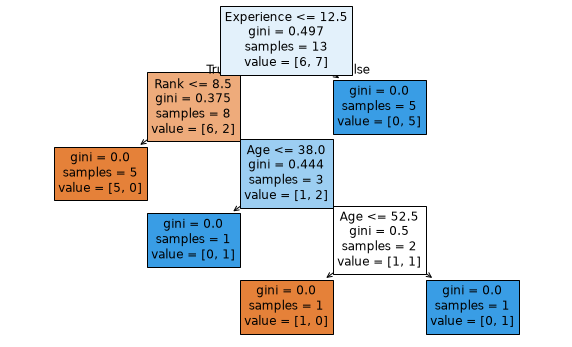

In [4]:
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(random_state=0)
dtree = dtree.fit(X, y)

plt.figure(figsize=(10, 6))
tree.plot_tree(dtree, feature_names=features, filled=True)
plt.show()

## Result Explained — Giải thích kết quả

Cây quyết định dùng các quyết định trước đó để tính khả năng bạn muốn đi xem một nghệ sĩ hài.

Đọc từng ô (node) của cây:

- **Dòng điều kiện**, ví dụ `Rank <= 6.5`: các nghệ sĩ có xếp hạng ≤ 6.5 đi theo nhánh **True** (trái), còn lại theo nhánh **False** (phải).
- **gini**: chất lượng của việc chia, luôn là số từ 0.0 đến 0.5 — `0.0` nghĩa là mọi mẫu cho cùng một kết quả, `0.5` là chia đúng một nửa.
- **samples**: số nghệ sĩ còn lại ở bước này.
- **value** = `[số NO, số YES]` (scikit-learn mới hiển thị dạng **tỉ lệ**).

### Gini

Cách chia mẫu ở trên dùng **Gini**:

```text
Gini = 1 - (x/n)² - (y/n)²
```

Trong đó `x` là số câu trả lời "YES" (đi), `n` là số mẫu, `y` là số câu trả lời "NO".

In [5]:
yes = (df["Go"] == 1).sum()
n = len(df)
no = n - yes
print("Gini tại gốc =", round(1 - (yes / n) ** 2 - (no / n) ** 2, 3))

Gini tại gốc = 0.497


## Predict Values — Dự đoán

Dùng cây quyết định để dự đoán giá trị mới.

Có nên đi xem show của một nghệ sĩ hài **người Mỹ (1), 40 tuổi, 10 năm kinh nghiệm, xếp hạng 7**?

In [6]:
new_show = pandas.DataFrame([[40, 10, 7, 1]], columns=features)
print(dtree.predict(new_show))

[0]


Nếu xếp hạng chỉ là **6** thì sao?

In [7]:
new_show = pandas.DataFrame([[40, 10, 6, 1]], columns=features)
print(dtree.predict(new_show))

[0]


`[1]` nghĩa là **"GO"** (nên đi), `[0]` nghĩa là **"NO"**.

## Different Results — Kết quả có thể khác nhau

Chạy cây quyết định nhiều lần (không đặt `random_state`), đôi khi bạn sẽ nhận kết quả khác — vì cây quyết định không đưa ra câu trả lời chắc chắn 100%, nó dựa trên **xác suất** kết quả, và câu trả lời có thể thay đổi.

---

## 🧠 Ghi nhớ nhanh

> - Cây quyết định: chia dữ liệu bằng các câu hỏi `đặc_trưng <= ngưỡng` để ra quyết định.
> - Dữ liệu phải là **số** → chuyển cột chữ bằng `df[col].map({...})`.
> - `DecisionTreeClassifier().fit(X, y)` · `tree.plot_tree(...)` · `.predict(...)`.
> - **Gini** = 1 - (x/n)² - (y/n)² (0 = thuần nhất, 0.5 = chia đôi).

---

## 📝 Exercise — Bài tập nhanh

**❓ Câu hỏi:** Vì sao cần dùng `map()` trước khi tạo cây quyết định?

- **A.** Để vẽ biểu đồ
- **B.** Để xoá dữ liệu trùng lặp
- **C.** Để chuyển các cột chữ (như quốc tịch) thành số
- **D.** Để sắp xếp dữ liệu

<details>
<summary>👉 Xem đáp án</summary>

✅ **Đáp án: C** — Để chuyển các cột chữ (như quốc tịch) thành số

</details>

---

[« Machine Learning - Train/Test](012_ml_train_test.ipynb) &nbsp;•&nbsp; [📚 Mục lục](../README.md) &nbsp;•&nbsp; [Machine Learning - Confusion Matrix »](014_ml_confusion_matrix.ipynb)